# CME538 - Introduction to Data Science

## Tutorial 3 - Parsing HTML and Working with Dates & Times

### Learning Objectives

After completing this tutorial, you should be comfortable:

* Understanding the overall structure of HTML tags
* Finding information of interest within a web page by examining its HTML source code
* Using Python and BeautifulSoup to extract information from HTML elements
* Using Python string methods to extract and manipulate information from text
* Creating and working with Python `datetime` objects
* Converting date and time information into Pandas datetime objects
* Extracting useful information from datetime columns for basic analysis

### Tutorial Structure

1. [What is HTML](#section1)
2. [Scraping The Guardian](#section2)
3. [Scraping quotes.toscrape.com](#section3)
4. [Working with Dates and Times](#section4)

   * 4.1. Python `datetime` objects
   * 4.2. Formatting dates and times
   * 4.3. Datetimes in Pandas
   * 4.4. Working with datetime columns


<a id="section1"></a>

# 1. What is HTML?

[W3Schools: HTML Introduction](https://www.w3schools.com/html/html_intro.asp)

- HTML stands for **HyperText Markup Language**.
- HTML is the standard markup language used to create web pages.
- It describes the **structure** of a web page.
- HTML consists of a series of **elements** that tell the browser how to display content.
- HTML elements label different types of content, such as **headings**, **paragraphs**, **links**, images, and more.

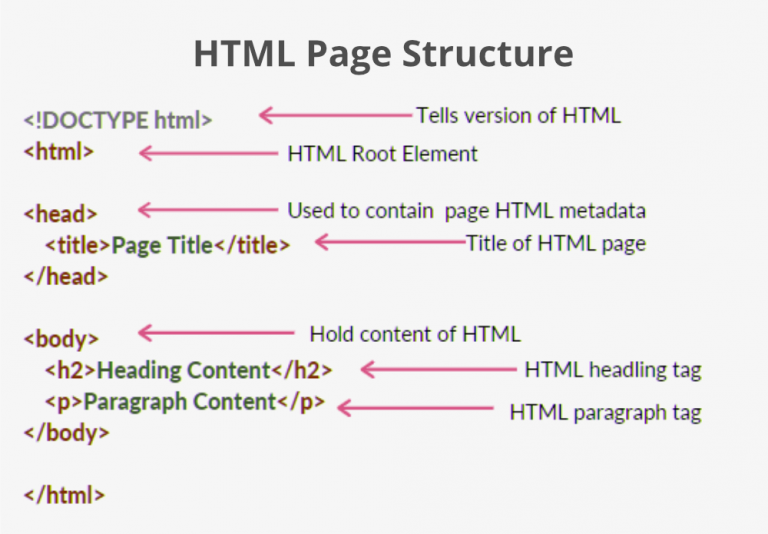 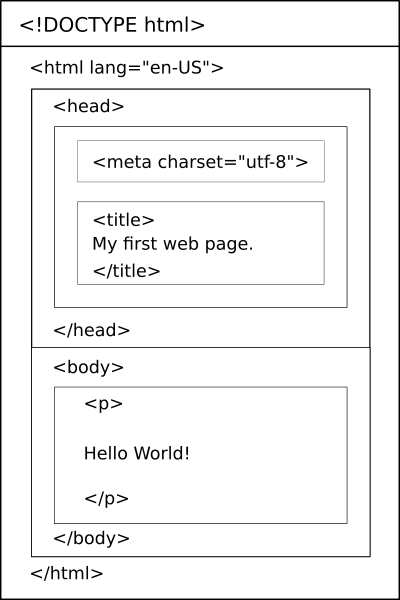

HTML tags look something like this (similar to XML syntax):

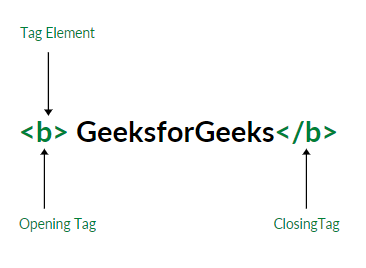

### An example of some HTML code

HTML uses **tags** to define the structure and content of a web page. For example, the code below uses a `<div>` element to contain an image:

In [ ]:
'''

<div>
<img src="attachment:image.png" width="400" align='left'/>
</div>

'''

Here:

- `<div>` is a **container element** that groups content together.
- `<img>` is an **image element** used to display an image.
- `src` specifies the **location of the image**.
- `width` controls the displayed width of the image.
- `align="left"` positions the image to the left.

When scraping a web page, we can inspect these HTML elements and their attributes to identify the information we want to extract.

<a id="section2"></a>

# 2. Scraping the Guardian

Let's scrape the best books of the 21st century, according to *The Guardian*.

We will use the `requests` library to send a request to the web page and retrieve its HTML source code.

In [ ]:
# Import the requests library for sending HTTP requests to web pages.
import requests


# URL of the web page we want to scrape.
url = 'https://www.theguardian.com/books/2019/sep/21/best-books-of-the-21st-century'


# Send a GET request to the web page.
response = requests.get(url)

# Check the HTTP response status to make sure the request was successful.
# A status code of 200 means the request was successful.
print(response)

If the request is successful, we should see:

`<Response [200]>`

The **200** status code means that the request was successful and the web server returned the requested page.

> **Note:** Web pages can change over time. The HTML structure and availability of a page may differ from when this tutorial was originally created.

To parse the HTML document, we will use **BeautifulSoup**, a Python library commonly used for parsing and extracting information from HTML.


If BeautifulSoup is not already installed in your environment, you can install it using the following command.


To parse our HTML document, we will use **BeautifulSoup**, a Python library commonly used for parsing HTML and extracting information from web pages.

In [ ]:
# Import BeautifulSoup for parsing HTML and extracting information from web pages.
from bs4 import BeautifulSoup

If you don't have this library installed, no worries! Let's `pip install` it now:


In [ ]:
!pip install bs4 # one time run! after installed, don't worry about rerunning.
!pip install beautifulsoup4


> **Note:** The installation cell only needs to be run if `beautifulsoup4` is not already installed. In most course environments, the library should already be available.

Let's start parsing the website data with `BeautifulSoup`.

The `response.text` object contains the HTML source code returned by the web page. We pass this HTML to `BeautifulSoup` and specify the `'html.parser'` parser.

We can inspect a small portion of the parsed HTML to confirm that the page was successfully loaded and parsed.

In [ ]:
# The full HTML source can be very long, so we will not print it.
# print(response.text)

# Create a BeautifulSoup object by parsing the HTML returned by the website.
# Use Python's built-in HTML parser.
html_soup = BeautifulSoup(response.text, 'html.parser')

# Preview the first 200 characters to confirm that the HTML was parsed successfully.
print(str(html_soup)[:200])

The output begins with:

`<!DOCTYPE html>`

This indicates that we are looking at the **HTML source code of the web page**.

We can also see elements such as `<html>`, `<head>`, and `<title>`. These are HTML tags that describe the structure of the page.

For example, the `<title>` element contains information about the page title:

`The 100 best books...`

We will now use BeautifulSoup to find specific HTML elements and extract the information we are interested in.

We are interested in extracting out a few specific tags, we can use the built-in `find_all` method:

In [ ]:
# Display the documentation for BeautifulSoup's find_all() method.
# This method is used to find all HTML elements matching a specified tag or criteria.
help(html_soup.find_all)

The `find_all()` method allows us to search the HTML document for **all elements that match a specified HTML tag**.

Let's find all the `<h2>` tags in the HTML document.

The Guardian page uses `<h2>` elements for several pieces of content, including the book titles. We can use `find_all()` to retrieve all elements with the `h2` tag.

In [ ]:
# Find all <h2> elements in the HTML document.
# find_all() returns all matching elements as a list.
book_titles = html_soup.find_all('h2')

# Display the list of <h2> elements that were found.
book_titles

In [ ]:
# Access the second <h2> element in the list.
# Python uses zero-based indexing, so index 1 refers to the second element.
print(book_titles[1])

We have found the HTML elements containing the book titles. However, `book_titles` contains the full HTML tags, not just the text.

We can use the `.text` attribute to extract the text contained inside an HTML element.

In [ ]:
# print out the text content of the tag
print(book_titles[1].text)

In [ ]:
# Iterate through all of the <h2> elements.
for title in book_titles:
    # Extract and print the text contained in each <h2> element.
    print(title.text)

The `<h2>` elements we extracted contain several pieces of information mixed together: the book's rank, title, and author/year.

For example, the information follows a repeating pattern:

1. Rank
2. Book title
3. Author and publication year

We want to separate this single list into three smaller lists so that each type of information can eventually become a separate DataFrame column.

For example:

**Original list:**

```text
[100, 'I Feel Bad About My Neck', 'by Nora Ephron (2006)',
 99, 'Broken Glass', 'by Alain Mabanckou (2005), ...',
 98, 'The Girl With the Dragon Tattoo', 'by Stieg Larsson (2005), ...']

In [ ]:
# Example of the scraped data:
# The information repeats in groups of three:
# rank → title → author/year

book_example = [
    100,
    'I Feel Bad About My Neck',
    'by Nora Ephron (2006)',
    99,
    'Broken Glass',
    'by Alain Mabanckou (2005), translated by Helen Stevenson (2009)',
    98,
    'The Girl With the Dragon Tattoo',
    'by Stieg Larsson (2005), translated by Steven T. Murray (2008)'
]

# We want to separate the original list into three lists:
# one for ranks, one for titles, and one for author/year information.

rank_list = [100, 99, 98]

title_list = [
    'I Feel Bad About My Neck',
    'Broken Glass',
    'The Girl With the Dragon Tattoo'
]

year_author_list = [
    'Nora Ephron (2006)',
    'Alain Mabanckou (2005)',
    'Stieg Larsson (2005)'
]

### List Comprehensions

We can use a **list comprehension** to create a new list from an existing iterable.

Before using a list comprehension, let's see how we could create a copy of a list using a regular `for` loop.

This approach works, but it requires several lines of code. We will use this as a comparison before introducing the more concise list comprehension syntax.

Maybe we can use `list comprehension` to iterate over the output:

In [ ]:
# Example list
my_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# Create an empty list to store the values we will generate.
copy_list = []

# Iterate through each item in the original list.
for i in my_list:
    # Add the current item to the new list.
    copy_list.append(i)

# Display the resulting list.
print(copy_list)

The same operation can be written more concisely using a **list comprehension**.

The general structure is:

`[expression for item in iterable]`

Here, each `item` from `my_list` is placed into the new list.

In [ ]:
# Example list
my_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# Use a list comprehension to create a new list
# containing each item from the original list.
copy_list = [item for item in my_list]

# Display the resulting list.
print(copy_list)

List comprehensions can do more than copy values.

We can apply an **expression or transformation** to each item as the list is created.

In the example below, `item + 2` is evaluated for every item in `my_list`.

In [ ]:
# A list comprehension can also transform each item while creating the new list.

# Add 2 to every item in my_list.
# The expression before "for" determines what is stored in the new list.
copy_list2 = [item + 2 for item in my_list]

# Display the resulting list.
print(copy_list2)

### Using `range()`

The `range()` function generates a sequence of numbers that we can use as indices.

The general syntax is:

`range(start, stop, step)`

- **start**: the index where we begin
- **stop**: the index where we stop (not included)
- **step**: how much the index increases each time

For example, `range(0, 6, 2)` generates the indices `0, 2, 4`.

In [ ]:
# range(start, stop, step)
# Start at index 0, stop before index 6, and move by 2 each time.
for index in range(0, 6, 2):
    print(index)

We can combine `range()` with a list comprehension to select elements at specific positions.

Suppose we want to select **every third item** from `my_list`.

We can:
1. Generate indices starting at 0.
2. Increase the index by 3 each time.
3. Use each index to access the corresponding item in `my_list`.

`len(my_list)` gives us the number of items in the list, so we can use it as the upper limit.

In [ ]:
# Display the original list so we can compare it with the selected values.
print(my_list)

# Select every third item from the list.
# Start at index 0, move forward by 3, and continue until the end of the list.
every_third_list = [my_list[index] for index in range(0, len(my_list), 3)]

# Display the selected items.
print(every_third_list)

Now let's apply the same idea to the book data we scraped from The Guardian.

Recall that the information follows a repeating pattern:

**rank → title → author/year**

Therefore, we can use `range()` with different starting indices to separate the three types of information.

### Extracting and Organizing the Book Information

We now have a list of text extracted from all of the `<h2>` elements.

Let's first create a simple Python list containing the text from each HTML element and inspect the first few entries.

In [ ]:
# Extract the text from every <h2> element and store the results in a list.
books = [title.text for title in book_titles]

# Display the first 10 items to inspect the structure of the scraped data.
books[0:10]

The data follows a repeating pattern:

- Index 0, 3, 6, ... → rank
- Index 1, 4, 7, ... → title
- Index 2, 5, 8, ... → author and year

We can use `range()` with a step size of `3` to separate these into different lists.

In [ ]:
# Extract the book ranks.
# Start at index 0 and select every third item.
rank = [books[index] for index in range(0, len(books), 3)]

# Extract the book titles.
# Start at index 1 and select every third item.
titles = [books[index] for index in range(1, len(books), 3)]

# Extract the author/year information.
# Start at index 2 and select every third item.
author_year = [books[index] for index in range(2, len(books), 3)]

# Inspect the first author/year entry.
author_year[0]

The `author_year` entries contain both the author's name and the publication year.

For example:

`'by Nora Ephron (2006)'`

We can use string methods to separate these pieces of information.

First, let's extract the year.

In [ ]:
# Split the string at '('.
# The last part contains the year, such as '2006)'.
# strip(')') removes the closing parenthesis.
print(author_year[0].split('(')[-1].strip(')'))

Now let's extract the author's name.

We can:
1. Split at `(` to separate the author from the year.
2. Select the first part.
3. Remove the word `by`.
4. Use `strip()` to remove extra whitespace.

In [ ]:
# Extract the author's name from the author/year string.
# split('(')[0] keeps the text before the publication year.
# replace('by', '') removes the word "by".
# strip() removes leading and trailing whitespace.
print(author_year[0].split('(')[0].replace('by', '').strip())

Some additional content on the page may have been captured by our `<h2>` selection.

Since the article contains exactly 100 ranked books, let's keep only the first 100 entries in each list.

In [ ]:
# Keep only the first 100 entries so that our lists contain the 100 ranked books.
rank = rank[0:100]
titles = titles[0:100]
author_year = author_year[0:100]

Finally, let's transform the `author_year` list into two separate lists:

- `year` → publication year
- `author` → author's name

We can use list comprehensions to apply the same string transformations to every entry.

In [ ]:
# Extract the publication year from each author/year entry.
year = [
    author_info.split('(')[-1].strip(')')
    for author_info in author_year
]

# Extract the author's name from each author/year entry.
author = [
    author_info.split('(')[0].replace('by', '').strip()
    for author_info in author_year
]

# Display the extracted years and authors.
print(year)
print(author)

### Creating a DataFrame

We have now separated the scraped information into four lists:

- `titles` → book titles
- `rank` → book rankings
- `year` → publication years
- `author` → author names

Because the lists have the same length and corresponding positions, we can combine them into a Pandas DataFrame.

In [ ]:
import pandas as pd

# Create a DataFrame from the lists we extracted from the web page.
# Each dictionary key becomes a column name.
# The values in each list become the rows of that column.
df_books = pd.DataFrame({
    'Titles': titles,
    'Rank': rank,
    'Year': year,
    'Author': author
})

# Display the first five rows to check that the DataFrame was created correctly.
df_books.head()

In [ ]:
# Display the last five rows to check the end of the DataFrame.
df_books.tail()

<a id="section3"></a>

# 3. One more example: `Quotes to Scrape`

Let's apply the same BeautifulSoup workflow to another website: `quotes.toscrape.com`.

This example will reinforce the general web-scraping process:

1. Send a request to the webpage.
2. Parse the HTML with BeautifulSoup.
3. Find the HTML elements containing the information we want.
4. Extract individual fields from those elements.
5. Iterate through all matching elements.
6. Store the extracted information in a DataFrame.

In [ ]:
# URL of the webpage we want to scrape.
url = 'http://quotes.toscrape.com/'

# Send a request to the webpage.
response = requests.get(url)

# Check the HTTP response status.
# A response of 200 indicates that the request was successful.
print(response)

In [ ]:
# Parse the webpage HTML using BeautifulSoup.
# 'html.parser' tells BeautifulSoup which parser to use.
soup = BeautifulSoup(response.text, "html.parser")

Each quote on the webpage is contained inside a `<div>` element with the class `quote`.

We can use `find_all()` with both the HTML tag and its class to find all of these quote containers.

In [ ]:
# Find all <div> elements with class="quote".
# Each matching element represents one quote.
quotes = soup.find_all("div", class_="quote")

# Check how many quotes were found.
print(len(quotes))

Let's inspect the first quote before extracting individual pieces of information from it.

Looking at the HTML structure helps us identify which tags contain the quote text, author, and tags.

In [ ]:
# Display the first quote and its HTML structure.
print(quotes[0])

Inside each quote, the actual quote text is stored in a `<span>` element with the class `text`.

We can use `find()` to locate the first matching element inside the quote.

In [ ]:
# Find the <span> containing the quote text.
quote_text = quotes[0].find('span', class_='text')

# Extract and display only the text contained in the HTML element.
print(quote_text.text)

The tags for each quote are contained inside a `<div>` with the class `tags`.

Let's first extract the entire tags section and inspect its text.

In [ ]:
# Find the <div> containing the quote's tags.
quote_tags = quotes[0].find('div', class_='tags')

# Display the text contained in the tags section.
print(quote_tags.text)

The extracted text contains the word `Tags:` and newline characters.

We want a cleaner representation where the individual tags are separated by commas.

We can use string methods to:
- remove `Tags:`
- remove extra whitespace
- replace newline characters with commas

In [ ]:
# Convert the extracted HTML text to a Python string.
# Remove the "Tags:" label and surrounding whitespace.
tags = str(quote_tags.text).replace("Tags:", "").strip()

# Replace newline characters with commas so the tags are easier to read.
tags = tags.replace("\n", ", ")

# Display the cleaned tags.
print(tags)

In [ ]:
# The same cleaning steps can be combined into one expression.
tags = (
    str(quote_tags.text)
    .replace("Tags:", "")
    .strip()
    .replace("\n", ", ")
)

print(tags)

We have successfully extracted the three pieces of information we need from one quote:

- quote text
- author
- tags

Now let's apply the same process to **every quote** on the page.

We will store the extracted information in a list called `data`.

For each quote, we will create a dictionary containing the three fields. Each dictionary will eventually represent one row of our DataFrame.

In [ ]:
# Create an empty list to store the extracted data.
data = []

# Iterate through every quote found on the webpage.
for quote in quotes:

    # Extract the quote text.
    text = quote.find('span', class_='text').text

    # Extract the author's name.
    author = quote.find('small', class_='author').text

    # Extract the tags.
    quote_tags = quote.find('div', class_='tags')

    # Clean the tags by removing the "Tags:" label
    # and replacing newline characters with commas.
    tags = (
        str(quote_tags.text)
        .replace("Tags:", "")
        .strip()
        .replace("\n", ", ")
    )

    # Store the information for this quote as a dictionary.
    # Each dictionary will become one row in the final DataFrame.
    data.append({
        'Quote': text,
        'Author': author,
        'Tags': tags
    })

Now that we have a list of dictionaries, we can pass it to `pd.DataFrame()`.

Each dictionary becomes a row, and the dictionary keys become the column names.

In [ ]:
# Convert the list of dictionaries into a Pandas DataFrame.
# Each dictionary represents one quote/row.
df_quotes = pd.DataFrame(data)

# Display the resulting DataFrame.
df_quotes

# 4. Working with Dates and Times

So far, we have worked with HTML and text data. Another common type of data encountered in real-world datasets is **date and time information**.

Dates and times often appear as text when data is first collected. For example:

```text
06/01/2014 00:00:00

In [ ]:
import pandas as pd

# Load the Uber ride dataset.
# The file is located in the same folder as this notebook.
uber_data = pd.read_csv('uber-raw-data-jun14.csv')

# Display the first five rows to inspect the dataset.
uber_data.head()

The `Date/Time` column contains the date and time of each Uber ride.

At the moment, Pandas has loaded these values as **text (`object`)**, rather than as datetime values. We can confirm this by checking the DataFrame's data types.

In [ ]:
# Check the data type of each column.
# Notice that Date/Time is currently stored as an object (text).
uber_data.dtypes

The `Date/Time` values are currently stored as strings.

This means Pandas does not yet recognize them as dates or times. For example, we cannot directly use datetime operations such as extracting the month or hour.

We can convert the column using Pandas' `pd.to_datetime()` function.

In [ ]:
# Convert the Date/Time column from strings to Pandas datetime objects.
uber_data['Date/Time'] = pd.to_datetime(uber_data['Date/Time'])

# Check the data type again to confirm the conversion.
uber_data.dtypes

The `Date/Time` column is now stored as a Pandas datetime type.

The exact resolution shown by Pandas may depend on the Pandas/Python version. For example, you may see `datetime64[us]` or `datetime64[ns]`.

The important change is that Pandas now recognizes these values as **dates and times**, which allows us to extract useful information such as the year, month, day, and hour.

In [ ]:
# Extract the year from each datetime value.
uber_data['Year'] = uber_data['Date/Time'].dt.year

# Extract the month from each datetime value.
uber_data['Month'] = uber_data['Date/Time'].dt.month

# Extract the day of the month from each datetime value.
uber_data['Day'] = uber_data['Date/Time'].dt.day

# Extract the hour from each datetime value.
uber_data['Hour'] = uber_data['Date/Time'].dt.hour

# Display the first few rows to check the new columns.
uber_data.head()

The new columns contain individual components of the datetime:

- `Year` → the year of the ride
- `Month` → the month of the ride
- `Day` → the day of the month
- `Hour` → the hour of the day

This makes it easier to analyze patterns in the data. For example, we can now investigate how the number of Uber rides changes throughout the day.

In [ ]:
# Count the number of rides that occurred during each hour of the day.
hourly_rides = uber_data['Hour'].value_counts().sort_index()

# Display the number of rides for each hour.
hourly_rides

The results show how the number of Uber rides varies throughout the day.

For example, there are relatively few rides during the early morning hours, while the number of rides increases substantially during the afternoon and early evening.

Because `Date/Time` contains both the date and time of each ride, we can use it as a **datetime index**. This will allow Pandas to organize the data chronologically and perform time-based operations such as grouping and resampling.

In [ ]:
# Set the Date/Time column as the DataFrame index.
# A datetime index allows Pandas to perform time-based operations.
uber_data = uber_data.set_index('Date/Time')

# Display the first few rows to inspect the new index.
uber_data.head()

The `Date/Time` column is now the **index** of the DataFrame.

Because the index contains datetime values, Pandas can use the date and time information directly for time-based analysis.

For example, we can select data for a particular date, find the earliest or latest observation, or group observations into larger time periods.

In [ ]:
# Find the earliest datetime in the dataset.
print("Start:", uber_data.index.min())

# Find the latest datetime in the dataset.
print("End:", uber_data.index.max())

Datetime objects also allow us to extract useful information directly from the date.

For example, we can determine which **day of the week** each ride occurred on.

Pandas provides the `.dt.day_name()` accessor for this.

In [ ]:
# Extract the day of the week from the Date/Time index.
# Since Date/Time is now the index, we work with uber_data.index.
uber_data['Day_Name'] = uber_data.index.day_name()

# Display the first few rows to check the new column.
uber_data.head()

In [ ]:
# Count the number of rides for each day of the week.
day_counts = uber_data['Day_Name'].value_counts()

# Display the counts.
day_counts

Once `Date/Time` has been converted to a `DatetimeIndex`, we can work directly with the index to extract information such as the day of the week.

This is different from extracting information from a regular DataFrame column.

### Datetime Resampling

Our dataset contains individual Uber rides recorded at different times throughout June 2014.

Instead of looking at every individual ride, we may want to summarize the data over larger time periods.

For example:

- How many rides occurred each day?
- How many rides occurred each week?
- How does the number of rides change over the month?

Pandas provides the `.resample()` method for this type of time-based aggregation.

Before using `.resample()`, the DataFrame needs a **datetime-based index**, which we have already created.

In [ ]:
# Count the number of Uber rides recorded on each day.
daily_rides = uber_data.resample('D').size()

# Display the daily ride counts.
daily_rides

The result contains one value for each day in June.

The index now represents the date, while the value represents the **number of rides recorded on that day**.

Notice that the frequency is shown as `D`, which indicates a daily frequency.

We can visualize these daily totals to make the pattern easier to interpret.

In [ ]:
# Plot the number of Uber rides recorded each day.
import matplotlib.pyplot as plt

daily_rides.plot(
    figsize=(12, 5),
    title='Uber Rides Per Day - June 2014'
)

# Label the axes to make the plot easier to interpret.
plt.xlabel('Date')
plt.ylabel('Number of Rides')

plt.show()

### Key Takeaway

Datetime conversion allows us to treat dates and times as structured data rather than ordinary text.

Once a column is converted to datetime, we can:

- extract components such as year, month, day, hour, and weekday;
- use dates as a DataFrame index;
- group and summarize observations over time using methods such as `.resample()`.